In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\civiljev\Export.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9822 entries, 0 to 9821
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9822 non-null   str  
 1   Message  9822 non-null   str  
 2   Status   9822 non-null   str  
dtypes: str(3)
memory usage: 230.3 KB


In [3]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    9249
0x252514     492
0x252501      43
0x252511      38
Name: count, dtype: int64

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9822 entries, 0 to 9821
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9822 non-null   str  
 1   Message  9822 non-null   str  
 2   Status   9822 non-null   str  
 3   Headers  9822 non-null   str  
dtypes: str(4)
memory usage: 307.1 KB


Odometer

In [5]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 9741 entries, 6360 to 9821
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             9741 non-null   str  
 1   Message             9741 non-null   str  
 2   Status              9741 non-null   str  
 3   Headers             9741 non-null   str  
 4   Odometer in meters  9741 non-null   int64
 5   Date                9741 non-null   str  
 6   Raw data            9741 non-null   str  
dtypes: int64(1), str(6)
memory usage: 608.8 KB
None


000101000005 -> 0x252514005910280869487063253305003C0E102D00000000EF00000007000061000000FFFFFFFFFFFFFFFFFFFF16800014D1C11000010100000500D09B44197E97C20A059A400000003803201264FFFFFF000017FFFFFFFFFF
000101000010 -> 0x252514005910A80869487063253305003C0E102D00000000F000000007000061000000FFFFFFFFFFFFFFFFFFFF16800015124310000101000010CDCC9C44157E97C2FE049A400000012803171196FFFFFF00001CFFFFFFFFFF
000101000010 -> 0x25251400590FEE0869487063253305003C0E102D00000000EF00000007000061000000FFFFFFFFFFFFFFFFFFFF168000149EFC10000101000010CD9C9C44137E97C234039A400000009A03181264FFFFFF000019FFFFFFFFFF
000101000010 -> 0x25251400590FDC0869487063253305003C0E102D00000000F000000007000061000000FFFFFFFFFFFFFFFFFFFF168000147A931000010100001000A09C449C8397C2A0089A400000006803181196FFFFFF00001CFFFFFFFFFF
000101000010 -> 0x25251400590FC40869487063253305003C0E102D00000000EE00000007000061000000FFFFFFFFFFFFFFFFFFFF168000145D341000010100001066969C44267E97C2C4029A40000000FF03211212FFFFFF000018FFFFFFFFFF
000101000010 ->

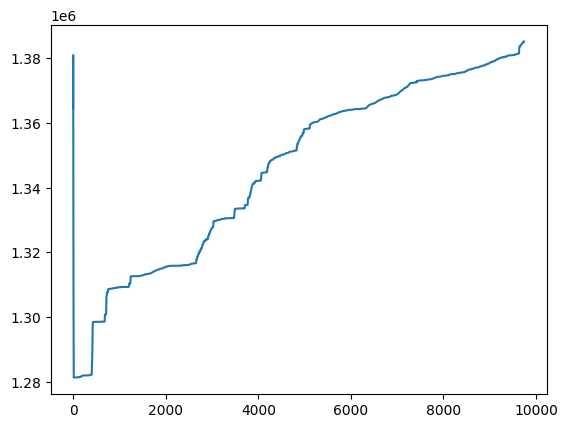

In [6]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [7]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            #print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 9733 entries, 9592 to 9247
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     9733 non-null   int64
 1   Date      9733 non-null   str  
 2   Raw data  9733 non-null   str  
dtypes: int64(1), str(2)
memory usage: 304.2 KB
None


260709155621 -> 714 -> 58.0 -> 0x252513005914800869487063253305003C0E102D0000003A5100000007000020000000FFFFFFFFFFFFFFFFFFFF00D50013E7113026070915562166E69C44F68097C223FA9940058000FF03701326FFFFFF0000290000FFFFFF


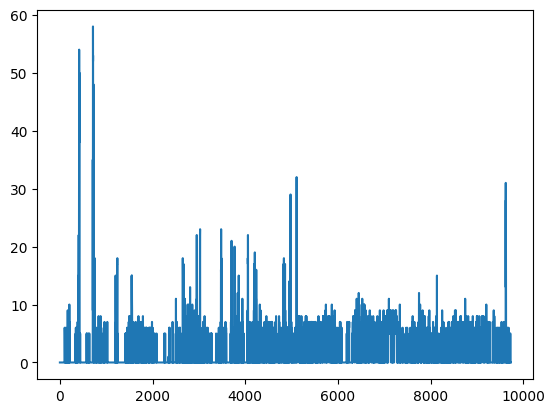

In [8]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])
    #print(raw_data_[i])

for i in range(0,len(speed)):
    if (y_axis[i]>55):
        print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

plt.plot(x_axis,y_axis)

Satellites

In [9]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)
unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<1:
        num_events=num_events+1
        print(unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,5],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 9741 entries, 6360 to 9821
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         9741 non-null   str  
 1   Message                         9741 non-null   str  
 2   Status                          9741 non-null   str  
 3   Headers                         9741 non-null   str  
 4   Satellites                      9741 non-null   int64
 5   Satellite_connection_indicator  9741 non-null   int64
 6   Raw data                        9741 non-null   str  
 7   date                            9741 non-null   str  
dtypes: int64(2), str(6)
memory usage: 684.9 KB
2026-07-09 13:54:41.535 -> 0 -> 0 -> 0x25251400590F1D0869487063253305003C0E102D000000640000000007000061000000FFFFFFFFFFFFFFFFFFFF69D50013D0AC1026070913544182DC00650AAB3A33714C00B50000000003181261FFFFFF000023FFFFFFFFFF
2026-07-09 13:55:42.627 -> 0 -> 0 -> 0x252513005914

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [10]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16)))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\civiljev\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 9741 entries, 0 to 9819
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9741 non-null   str  
 1   Message  9741 non-null   str  
 2   Status   9741 non-null   str  
 3   Headers  9741 non-null   str  
dtypes: str(4)
memory usage: 380.5 KB


Power

In [11]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
Index: 9741 entries, 0 to 9819
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9741 non-null   str  
 1   Message  9741 non-null   str  
 2   Status   9741 non-null   str  
 3   Headers  9741 non-null   str  
dtypes: str(4)
memory usage: 380.5 KB
               Date  int_bat
0     2607010040269    13.09
1     2607010140269    13.09
2     2607010240269    13.09
3     2607010340259    13.07
4     2607010440259    13.06
...             ...      ...
9736  2607312040553    13.31
9737  2607312041223    12.62
9738  2607312041453    12.70
9739  2607312042123    12.26
9740  2607312104483     2.61

[9741 rows x 2 columns]


Pánico

In [12]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]

unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])    

print("len aux_cad: ",len(aux_cad))

<class 'pandas.DataFrame'>
Index: 9741 entries, 0 to 9819
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9741 non-null   str  
 1   Message  9741 non-null   str  
 2   Status   9741 non-null   str  
 3   Headers  9741 non-null   str  
dtypes: str(4)
memory usage: 380.5 KB
len aux_cad:  9741


HL

In [13]:
hl=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\civiljev\historicallocations.xlsx')
hl.info()

<class 'pandas.DataFrame'>
RangeIndex: 9635 entries, 0 to 9634
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sequence     9635 non-null   int64  
 1   Unit         9635 non-null   str    
 2   Events       9635 non-null   str    
 3   Date         9635 non-null   str    
 4   Landmark     2 non-null      str    
 5   Address      9635 non-null   str    
 6   Speed        9635 non-null   int64  
 7   Temperature  0 non-null      float64
 8   Driver       0 non-null      float64
 9   Latitude     9635 non-null   float64
 10  Longitude    9635 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 828.1 KB


In [14]:
hl['Events'].value_counts()

Events
Idle - Stop           5848
Drive                 2985
Parked                 343
Ignición Apagada       216
Ignición Encendida     205
Towing/Drifting?        36
Geofence IN              1
Geofence OUT             1
Name: count, dtype: int64

In [15]:
hl_towing=hl[hl['Events'].str.contains('Towing')]
hl_towing

,Sequence,Unit,Events,Date,Landmark,Address,Speed,Temperature,Driver,Latitude,Longitude
8926,709,SY007CF0088H8,Towing/Drifting?,Jul 09 2026 11:01 AM,NaN,"Av 30 De Agosto 100, Pereira, Risaralda",48,NaN,NaN,4.815057,-75.763687
8927,708,SY007CF0088H8,Towing/Drifting?,Jul 09 2026 11:00 AM,NaN,"A Manizales-83, Pereira, Risaralda, Colombia",24,NaN,NaN,4.813365,-75.766975
8928,707,SY007CF0088H8,Towing/Drifting?,Jul 09 2026 11:00 AM,NaN,"A Manizales-58, Pereira, Risaralda",19,NaN,NaN,4.813068,-75.767021
8929,706,SY007CF0088H8,Towing/Drifting?,Jul 09 2026 11:00 AM,NaN,"A Cali-28, Pereira, Risaralda",17,NaN,NaN,4.812803,-75.766777
8931,704,SY007CF0088H8,Towing/Drifting?,Jul 09 2026 11:00 AM,NaN,"A Pereira-25, Pereira, Risaralda",16,NaN,NaN,4.812356,-75.766769
8932,703,SY007CF0088H8,Towing/Drifting?,Jul 09 2026 11:00 AM,NaN,"Glorieta Mercasa-11, Pereira, Risaralda",16,NaN,NaN,4.812233,-75.767075
8933,702,SY007CF0088H8,Towing/Drifting?,Jul 09 2026 11:00 AM,NaN,"A Pereira-65, Pereira, Risaralda",9,NaN,NaN,4.812293,-75.767265
8934,701,SY007CF0088H8,Towing/Drifting?,Jul 09 2026 10:59 AM,NaN,"Av 29-93, Pereira, Risaralda",17,NaN,NaN,4.813141,-75.767258
8935,700,SY007CF0088H8,Towing/Drifting?,Jul 09 2026 10:58 AM,NaN,"Av 30 De Agosto 100, Pereira, Risaralda",53,NaN,NaN,4.815024,-75.764084
8936,699,SY007CF0088H8,Towing/Drifting?,Jul 09 2026 10:56 AM,NaN,"Av 30 De Agosto, Pereira, Risaralda",51,NaN,NaN,4.812214,-75.753822


In [16]:
hl_ignition=hl[hl['Events'].str.contains('Ignición')]
hl_ignition.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\civiljev\ignition.csv')